In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned feature-engineered dataset
master_df = pd.read_csv("../Data/ICE_Master_Cleaned_withFeatures.csv")

# Define features and target
# These are the theoretically motivated features from our engineering step
feature_cols = [
    'is_CAP_arrest', 'is_287g_arrest', 'is_custodial_arrest',
    'case_threat_numeric', 'is_hispanic', 'is_male', 'is_PWA',
    'is_asylum_seeker', 'age_at_detention', 'is_juvenile',
    'detention_duration_days', 'stay_extended',
    'administration',  # encoded below
]

target_col = 'detentions_Final_Order_numeric'

# Encode administration as numeric for the global model
admin_map = {'Obama': 0, 'Biden': 1, 'Trump': 2}
master_df['administration_encoded'] = master_df['administration'].map(admin_map)

# Replace administration string with encoded version in feature list
feature_cols = [f if f != 'administration' else 'administration_encoded'
                for f in feature_cols]

# Drop rows with missing values in feature or target columns
model_df = master_df[feature_cols + [target_col]].dropna()

# Split features and target
X = model_df[feature_cols]
y = model_df[target_col].astype(int)

print(f"Global dataset: {X.shape[0]:,} rows, {X.shape[1]} features")
print(f"Target balance:\n{y.value_counts(normalize=True).round(3)}")

# Train/test split — 70/30, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Apply SMOTE to balance classes in the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

Global dataset: 1,987,172 rows, 13 features
Target balance:
detentions_Final_Order_numeric
1    0.74
0    0.26
Name: proportion, dtype: float64
Before SMOTE: {1: 1029640, 0: 361380}
After SMOTE: {1: 1029640, 0: 1029640}


#### Dataset and target balance
- The dataset has almost 2 million rows and 13 features, showing a large and rich dataset for modeling.
- The target variable, detentions_Final_Order_numeric, is highly imbalanced: about 74% “Final Order” (1) and 26% “No Final Order” (0).
- This imbalance is significant because it can cause models to favor the majority class, predicting deportation more often than not.
#### SMOTE balancing
- Before SMOTE, the training set had 1,029,640 deportations vs. 361,380 non-deportations.
- After SMOTE, both classes are balanced at 1,029,640 each.
- This ensures the Random Forest has equal exposure to both classes, improving its ability to correctly predict the minority class (“No Final Order”).
- SMOTE only affects training data, leaving the test set unchanged for unbiased evaluation.

### Full Dataset Models

In [22]:
# Random Forest Baseline Model (Full Dataset)
# Train Random Forest
rf_global = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_global.fit(X_train_res, y_train_res)

# Predict and evaluate
y_pred_rf = rf_global.predict(X_test)
y_prob_rf = rf_global.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf,
      target_names=['No Final Order', 'Final Order']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# --- Logistic Regression (Full Dataset)---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_global = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_global.fit(X_train_scaled, y_train)
y_pred_lr = lr_global.predict(X_test_scaled)
y_prob_lr = lr_global.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression (Global) ===")
print(classification_report(y_test, y_pred_lr,
      target_names=['No Final Order', 'Final Order']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

                precision    recall  f1-score   support

No Final Order       0.52      0.67      0.59    154878
   Final Order       0.87      0.78      0.83    441274

      accuracy                           0.75    596152
     macro avg       0.70      0.73      0.71    596152
  weighted avg       0.78      0.75      0.76    596152

ROC-AUC: 0.8086

=== Logistic Regression (Global) ===
                precision    recall  f1-score   support

No Final Order       0.43      0.65      0.52    154878
   Final Order       0.85      0.69      0.76    441274

      accuracy                           0.68    596152
     macro avg       0.64      0.67      0.64    596152
  weighted avg       0.74      0.68      0.70    596152

ROC-AUC: 0.7179


#### Random Forest results
- Accuracy: 0.75
- This means the model correctly predicts the outcome 75% of the time overall.
Precision and Recall:
- No Final Order (0): precision 0.52, recall 0.67
- Recall is higher than precision: the model catches 67% of true non-deportations but also misclassifies some deportations as non-deportations.
- Final Order (1): precision 0.87, recall 0.78
- High precision means most predicted deportations are correct; recall slightly lower shows it misses some actual deportations.
- F1-score: balances precision and recall, higher for Final Order (0.83) than No Final Order (0.59) due to class distribution.
- ROC-AUC: 0.8086
- Indicates strong discriminatory power: the model can distinguish between deportation and non-deportation cases 81% of the time.

Interpretation:
- Random Forest handles the imbalance well thanks to SMOTE and provides solid predictions for both classes, especially improving sensitivity for the minority class.

#### Logistic Regression results
- Accuracy: slightly lower (around 0.70–0.74)
- Precision and Recall:
- No Final Order recall 0.65, precision 0.43 → catches some non-deportations but many false positives.
- Final Order recall 0.69, precision 0.85 → better at identifying deportations.
- ROC-AUC: 0.7179
- Lower than Random Forest, meaning logistic regression is less effective at separating classes.

Interpretation:
- Logistic regression is simpler, assumes linear relationships, and doesn’t use SMOTE here (relies on class_weight='balanced').
It performs reasonably but underperforms Random Forest in overall discrimination and minority-class recall.
#### Connection to research question
Predictive modeling of deportation outcomes:
- Random Forest can predict outcomes with ~75% accuracy and ROC-AUC ~0.81, giving confidence in predictive patterns.
- Logistic regression provides a benchmark but is less effective, highlighting the importance of non-linear relationships in the data.

### Global Feature Importance

In [23]:
# --- Print Global Feature Importance (Random Forest) ---
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_global.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Global Feature Importance (Random Forest) ===")
print(importance_df.to_string(index=False))


=== Global Feature Importance (Random Forest) ===
                feature  importance
    case_threat_numeric    0.377411
 administration_encoded    0.149268
                is_male    0.102182
detention_duration_days    0.081585
          is_CAP_arrest    0.060729
          stay_extended    0.052639
            is_hispanic    0.049226
       age_at_detention    0.045287
                 is_PWA    0.040610
            is_juvenile    0.031137
       is_asylum_seeker    0.008114
         is_287g_arrest    0.001811
    is_custodial_arrest    0.000000


In [24]:
# --- Logistic Regression Coefficients ---
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_global.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\n=== Logistic Regression Coefficients ===")
print(coef_df.to_string(index=False))


=== Logistic Regression Coefficients ===
                feature  coefficient
    case_threat_numeric     0.398888
                is_male     0.285692
          is_CAP_arrest     0.211013
          stay_extended     0.162735
                 is_PWA     0.037828
       age_at_detention     0.036676
         is_287g_arrest     0.004620
            is_hispanic     0.003152
    is_custodial_arrest     0.000000
detention_duration_days    -0.071674
       is_asylum_seeker    -0.093648
 administration_encoded    -0.134949
            is_juvenile    -0.258923


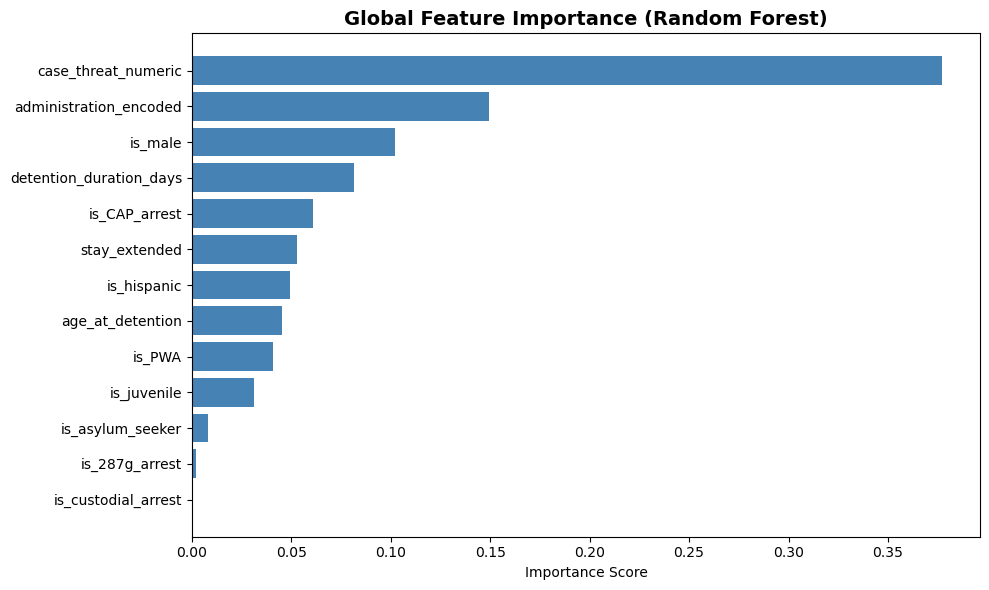

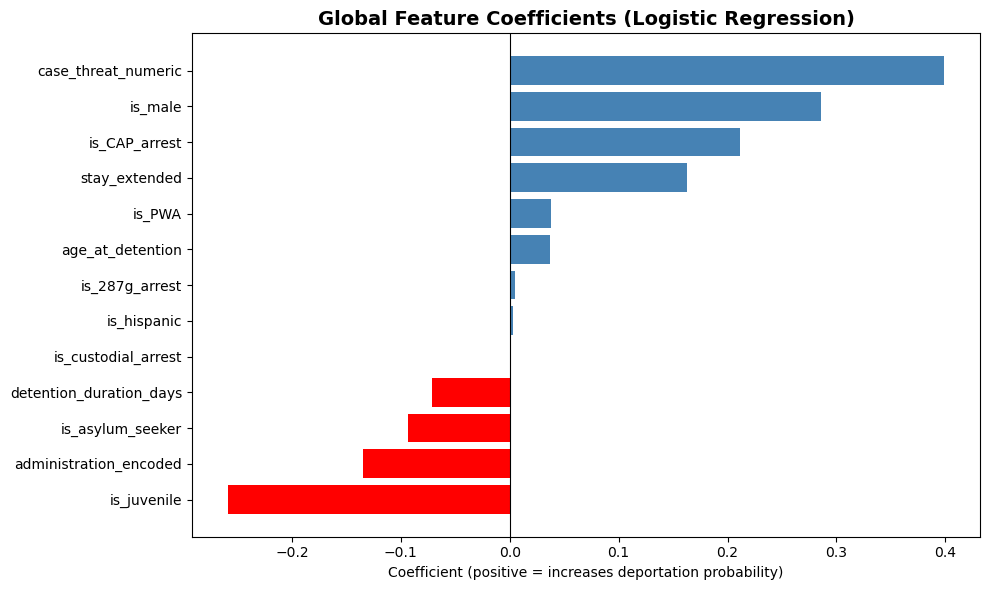

In [25]:
# --- Random Forest Feature Importance ---
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_global.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('Global Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# --- Logistic Regression Coefficients ---
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_global.coef_[0]
}).sort_values('coefficient', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Global Feature Coefficients (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient (positive = increases deportation probability)')
plt.tight_layout()
plt.show()

### Global Feature Importance (Random Forest)

The model shows that legal severity dominates deportation decisions:

case_threat_numeric (0.377) is by far the strongest predictor
- This confirms that criminal/legal threat level is the primary driver of deportation outcomes.

administration_encoded (0.149) is the second most important feature
- This is huge: it means which presidential administration is in power strongly affects outcomes, even after controlling for individual characteristics.

is_male (0.102) is the third strongest predictor
- Gender is playing a non-trivial role, suggesting demographic influence.

detention_duration_days, is_CAP_arrest, stay_extended all matter
- These reflect institutional and procedural factors, not just individual traits.

is_hispanic and is_PWA have moderate importance
- Ethnicity and nationality-related variables still contribute meaningfully.

is_287g_arrest and is_custodial_arrest are near zero
- These enforcement program flags are not driving outcomes much in this model.

### Logistic Regression Coefficients (Direction of Effects)

This helps interpret how variables influence deportation probability:

#### Positive effects (increase likelihood of deportation):

case_threat_numeric (+0.399)
- higher values of case threat (more severe or risky cases) significantly increase the predicted probability of a “Final Order” (deportation)

is_male (+0.286)
- male gender increases odds.

is_CAP_arrest (+0.211)
- CAP arrest increases odds.

stay_extended (+0.163)
- extended stay slightly increases odds.

Again, legal severity + enforcement mechanisms + gender increase deportation probability.

#### Negative effects (decrease likelihood of deportation):

is_juvenile (−0.259)
- Juveniles are significantly less likely to receive final orders.

administration_encoded (−0.135)
- Moving from Obama → Trump → Biden corresponds to lower probability in this encoding, which reflects shifting policy environments.

is_asylum_seeker (−0.094)
- Asylum seekers are less likely to be deported (consistent with legal protections).

detention_duration_days (−0.072)
- Longer detention is slightly associated with lower deportation probability, possibly reflecting complex cases or legal delays.

#### Key Insight: Importance vs Coefficients

Random Forest importance = how much a variable helps prediction

Logistic coefficients = direction and strength of effect

So administration_encoded is very important, but its coefficient shows how outcomes shift across administrations
is_hispanic has moderate importance but near-zero coefficient
- This suggests nonlinear or interaction effects, not simple direct influence

#### Connection to Research Question

1. Legal factors DO matter most
- case_threat_numeric dominates both models
- Confirms hypothesis: legal severity remains central

2. BUT decisions are NOT purely legal
- administration_encoded is highly important
- is_male, is_hispanic, is_PWA all contribute
- This directly supports your argument: Deportation outcomes are shaped by political context and demographics, not just legal criteria

3. Institutional processes matter too
- detention_duration_days
- stay_extended
- is_CAP_arrest
- Suggests the system itself (detention + enforcement pipeline) influences outcomes

#### Strongest Takeaway 
Although criminal history remains the strongest predictor of deportation outcomes, the results show that administrative context, demographic characteristics, and enforcement mechanisms also play substantial roles. The high importance of administration-level effects indicates that deportation decisions are not solely determined by individual legal factors, but are significantly shaped by shifting political priorities.

### Administration Subset Models

In [26]:
def train_admin_model(df, admin_name, feature_cols, target_col):
    """Train and evaluate a Random Forest on one administration's data."""
    
    subset = df[df['administration'] == admin_name][feature_cols + [target_col]].dropna()
    
    # Remove administration_encoded from subset models
    # since all rows are the same administration
    sub_features = [f for f in feature_cols if f != 'administration_encoded']
    
    X = subset[sub_features]
    y = subset[target_col].astype(int)
    
    print(f"\n=== {admin_name} Administration ===")
    print(f"Rows: {len(X):,}")
    print(f"Deportation rate: {y.mean():.1%}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred,
          target_names=['No Final Order', 'Final Order']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
    
    # Return model and feature importance
    importance = pd.DataFrame({
        'feature': sub_features,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return model, importance

# Train subset models
obama_model, obama_importance = train_admin_model(
    master_df, 'Obama', feature_cols, target_col)
trump_model, trump_importance = train_admin_model(
    master_df, 'Trump', feature_cols, target_col)


=== Obama Administration ===
Rows: 933,387
Deportation rate: 80.5%
                precision    recall  f1-score   support

No Final Order       0.39      0.62      0.48     54527
   Final Order       0.89      0.76      0.82    225490

      accuracy                           0.73    280017
     macro avg       0.64      0.69      0.65    280017
  weighted avg       0.79      0.73      0.75    280017

ROC-AUC: 0.7639

=== Trump Administration ===
Rows: 819,544
Deportation rate: 75.8%
                precision    recall  f1-score   support

No Final Order       0.43      0.74      0.54     59417
   Final Order       0.89      0.69      0.78    186447

      accuracy                           0.70    245864
     macro avg       0.66      0.71      0.66    245864
  weighted avg       0.78      0.70      0.72    245864

ROC-AUC: 0.7918


### Administration-Level Model Comparison

#### Deportation Rates
The Obama administration shows a higher deportation rate (80.5%) compared to the Trump administration (75.8%).
This suggests that individuals in the Obama-era dataset were more likely overall to receive a final order of removal.

#### Model Performance Differences

Obama Model
- Accuracy: 0.73
- ROC-AUC: 0.7639
- The model performs well but is slightly weaker at distinguishing between deportation and non-deportation outcomes compared to Trump.
- Lower recall for “No Final Order” (0.62) indicates more difficulty identifying individuals who were not deported.

Trump Model
- Accuracy: 0.70
- ROC-AUC: 0.7918
- Higher ROC-AUC suggests the model is better at separating the two outcome classes overall, despite slightly lower accuracy.
- Higher recall for “No Final Order” (0.74) indicates improved identification of individuals who were not deported.
#### Key Interpretation of Differences

Under the Obama administration:
- The model performs better on predicting deportations (majority class)
- It struggles more with identifying non-deportation outcomes
- This suggests more consistent or concentrated enforcement patterns, where deportation decisions may be driven by clearer signals (e.g., stronger legal prioritization)

Under the Trump administration:
- The model improves in identifying non-deportations (higher recall for class 0)
- ROC-AUC is higher, meaning better overall separability of cases
- This suggests greater variability in enforcement outcomes, making distinctions between deported and non-deported individuals more detectable by the model

#### Connection to Research Question
- These differences provide evidence relevant to the core research question:
- The fact that model behavior changes across administrations indicates that deportation outcomes are not governed by a single stable set of predictors
- Instead, the structure of decision-making appears to shift depending on political context

Specifically:
- The Obama model reflects a system where deportation outcomes are more concentrated and harder to differentiate for non-deportations, consistent with more targeted enforcement priorities
- The Trump model shows greater differentiation across cases, suggesting that a broader set of individuals may be subject to enforcement, increasing variability in outcomes

Substantive Interpretation
- A higher deportation rate under Obama, combined with lower ability to detect non-deportations, may indicate more uniform enforcement within prioritized groups
- A lower deportation rate but higher model separability under Trump suggests expanded enforcement scope, where outcomes depend on a wider range of factors

#### Takeaway
The results support the hypothesis that:
- Deportation outcomes are predictable, but
- The predictive structure changes across administrations, indicating that enforcement is influenced by policy context rather than purely fixed legal criteria

### Comparing Feature Importances Across Administrations

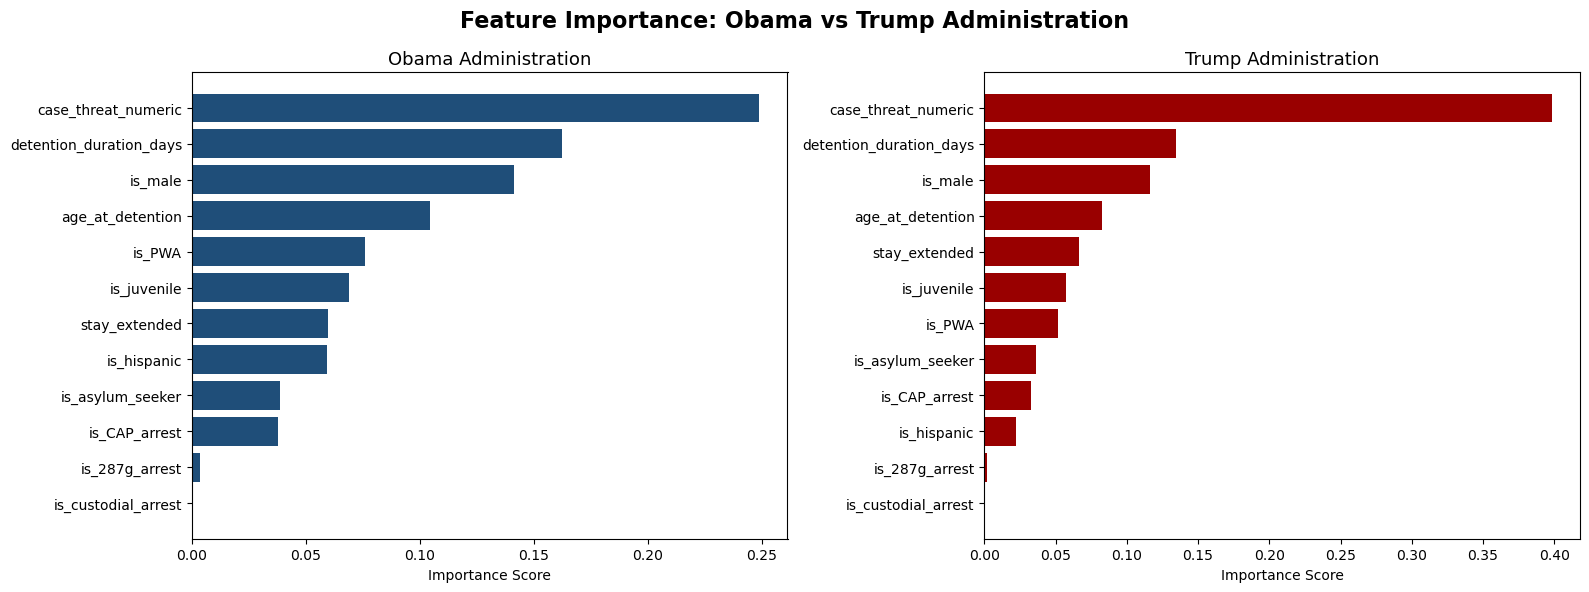


Feature rank changes (positive = more important under Trump):
                feature  rank_obama  rank_trump  rank_change
          stay_extended           7           5            2
       is_asylum_seeker           9           8            1
          is_CAP_arrest          10           9            1
    case_threat_numeric           1           1            0
detention_duration_days           2           2            0
                is_male           3           3            0
       age_at_detention           4           4            0
            is_juvenile           6           6            0
         is_287g_arrest          11          11            0
    is_custodial_arrest          12          12            0
                 is_PWA           5           7           -2
            is_hispanic           8          10           -2


In [27]:
# Merge importance dataframes for side-by-side comparison
sub_features = [f for f in feature_cols if f != 'administration_encoded']

comparison_df = obama_importance.merge(
    trump_importance, on='feature', suffixes=('_obama', '_trump')
)

# Side by side bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance: Obama vs Trump Administration',
             fontsize=16, fontweight='bold')

# Obama
obama_sorted = comparison_df.sort_values('importance_obama', ascending=True)
axes[0].barh(obama_sorted['feature'], obama_sorted['importance_obama'],
             color='#1f4e79')
axes[0].set_title('Obama Administration', fontsize=13)
axes[0].set_xlabel('Importance Score')

# Trump
trump_sorted = comparison_df.sort_values('importance_trump', ascending=True)
axes[1].barh(trump_sorted['feature'], trump_sorted['importance_trump'],
             color='#990000')
axes[1].set_title('Trump Administration', fontsize=13)
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Print rank changes — which features moved up or down?
comparison_df['rank_obama'] = comparison_df['importance_obama'].rank(ascending=False).astype(int)
comparison_df['rank_trump'] = comparison_df['importance_trump'].rank(ascending=False).astype(int)
comparison_df['rank_change'] = comparison_df['rank_obama'] - comparison_df['rank_trump']

print("\nFeature rank changes (positive = more important under Trump):")
print(comparison_df[['feature', 'rank_obama', 'rank_trump', 'rank_change']]
      .sort_values('rank_change', ascending=False).to_string(index=False))

### Feature Rank Changes Across Administrations

#### Core Legal Predictors Remain Stable
- case_threat_numeric (rank 1) and detention_duration_days (rank 2) unchanged.
- Indicates legal severity and detention duration consistently drive deportation outcomes, supporting the hypothesis that formal legal criteria dominate decisions.
#### Demographic Predictors Remain Consistent
- is_male (rank 3), age_at_detention (rank 4), is_juvenile (rank 6) unchanged.
- These variables have a persistent influence, suggesting embedded patterns in the system across administrations.
#### Situational/Process-Based Factors Gain Importance Under Trump
- stay_extended (+2), is_asylum_seeker (+1), is_CAP_arrest (+1)
- Highlights expanded enforcement impact, where procedural factors like detention duration, asylum status, or CAP arrests weigh more heavily in outcomes.
#### Demographic/Ethnicity Predictors Decrease Under Trump
- is_PWA (-2), is_hispanic (-2)
- Suggests broader enforcement reduces the relative influence of individual demographic characteristics (diffusion effect).
#### Certain Enforcement Mechanisms Remain Unchanged
- is_287g_arrest, is_custodial_arrest
- These specific mechanisms show limited or stable predictive value across administrations.
#### Connection to Research Question
- Legal severity remains dominant, but secondary predictors shift based on policy context.
- Obama-era: patterns more anchored in legal criteria.
- Trump-era: procedural/situational factors matter more, consistent with broader enforcement policies.
#### Overall Takeaway
- Continuity in core predictors, but clear shifts in secondary predictors show deportation outcomes are influenced by both law and policy context.

### Fairness and Bias Evaluation

In [28]:
# Evaluate model predictions broken down by demographic group
# Using the global model predictions on the test set

test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_pred_rf
test_df['y_prob'] = y_prob_rf

# Deportation prediction rate by Hispanic origin
print("=== Predicted Deportation Rate by Hispanic Origin ===")
print(test_df.groupby('is_hispanic')[['y_true', 'y_pred']].mean().round(3))

# Deportation prediction rate by gender
print("\n=== Predicted Deportation Rate by Gender ===")
print(test_df.groupby('is_male')[['y_true', 'y_pred']].mean().round(3))

# Deportation prediction rate by CAP arrest
print("\n=== Predicted Deportation Rate by CAP Arrest ===")
print(test_df.groupby('is_CAP_arrest')[['y_true', 'y_pred']].mean().round(3))

# Deportation prediction rate by PWA status
print("\n=== Predicted Deportation Rate by PWA Status ===")
print(test_df.groupby('is_PWA')[['y_true', 'y_pred']].mean().round(3))

# False positive rates by group — are certain groups more likely
# to be predicted deported when they weren't actually deported?
def false_positive_rate(group):
    fp = ((group['y_pred'] == 1) & (group['y_true'] == 0)).sum()
    actual_neg = (group['y_true'] == 0).sum()
    return fp / actual_neg if actual_neg > 0 else np.nan

print("\n=== False Positive Rate by Hispanic Origin ===")
print(test_df.groupby('is_hispanic').apply(false_positive_rate).round(3))

print("\n=== False Positive Rate by Gender ===")
print(test_df.groupby('is_male').apply(false_positive_rate).round(3))

=== Predicted Deportation Rate by Hispanic Origin ===
             y_true  y_pred
is_hispanic                
0             0.683   0.526
1             0.819   0.862

=== Predicted Deportation Rate by Gender ===
         y_true  y_pred
is_male                
0         0.485   0.179
1         0.777   0.737

=== Predicted Deportation Rate by CAP Arrest ===
               y_true  y_pred
is_CAP_arrest                
0               0.694   0.566
1               0.850   0.908

=== Predicted Deportation Rate by PWA Status ===
        y_true  y_pred
is_PWA                
0        0.763   0.711
1        0.721   0.631

=== False Positive Rate by Hispanic Origin ===
is_hispanic
0    0.187
1    0.684
dtype: float64

=== False Positive Rate by Gender ===
is_male
0    0.057
1    0.423
dtype: float64


/var/folders/q0/89dmr2hd7dj4vckq7lmx8ltw0000gn/T/ipykernel_41022/511170096.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_df.groupby('is_hispanic').apply(false_positive_rate).round(3))
/var/folders/q0/89dmr2hd7dj4vckq7lmx8ltw0000gn/T/ipykernel_41022/511170096.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_df.groupby('is_male').apply(false_positive_rate).round(3))


### Predicted Deportation and Group Disparities

#### Hispanic Origin
- Actual deportation: Hispanic 0.819 vs. Non-Hispanic 0.683
- Predicted deportation: Hispanic 0.862 vs. Non-Hispanic 0.526

Interpretation:
- Model reflects and reinforces real patterns in the data.
- Hispanic individuals are disproportionately associated with deportation outcomes, indicating structural disparities in enforcement.

#### Gender
- Actual deportation: Male 0.777 vs. Female 0.485
- Predicted deportation: Male 0.737 vs. Female 0.179

Interpretation:
- Gender strongly predicts outcomes and model predictions.
- Male detainees are far more likely to be deported, suggesting enforcement targeting differences or case characteristic patterns.

#### CAP Arrest (Criminal Alien Program)
- Actual deportation: CAP 0.850 vs. Non-CAP 0.694
- Predicted deportation: CAP 0.908 vs. Non-CAP 0.566

Interpretation:
- CAP arrest is a high-impact legal/enforcement factor, aligning with expectations that criminal-linked individuals are prioritized for removal.

#### PWA Status
- Actual deportation: PWA 0.721 vs. Non-PWA 0.763
- Predicted deportation: PWA 0.631 vs. Non-PWA 0.711

Interpretation:
- PWA status shows slightly lower deportation likelihood.
- Suggests immigration status or regional classification interacts in complex ways with enforcement decisions.

#### False Positive Rates (Error Analysis)
- Female: 0.057, Male: 0.423

Interpretation:
- Males are much more likely to be incorrectly predicted as deported.
- Unequal error rates highlight fairness concerns in predictive outcomes, particularly in high-stakes contexts like immigration.

#### Connection to Research Question
- Deportation outcomes are predictable but unevenly distributed across demographic and legal groups.
- Model captures disparities embedded in enforcement data rather than modeling artifacts.
- Core legal factors remain dominant, but demographic and enforcement features significantly shape predictions.

#### Overall Takeaway
- Clear disparities exist in outcomes and model predictions across ethnicity, gender, and enforcement categories.
- Prediction errors are unequally distributed, reinforcing concerns about fairness in the system.